# Degree Distribution Analysis
Explore the degree distribution of any NetworkX graph — summary stats, histogram, log-log plot, and a ranked node table.

In [1]:
import collections
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

### 1. Load or Create a Graph
Swap in your own graph — any `nx.Graph` or `nx.DiGraph` works.

In [35]:
dataset = "2wiki"

G = nx.read_graphml(f"/home/gbalanos/GloRAG-Ex/code/KGs/lightrag/{dataset}/graph_chunk_entity_relation.graphml")

print(f"Nodes: {G.number_of_nodes()}  |  Edges: {G.number_of_edges()}")
print(f"Directed: {G.is_directed()}")

Nodes: 4165  |  Edges: 3916
Directed: False


### 2. Compute Degree Distribution

In [36]:
def degree_distribution(G):
    """Returns a sorted dict of {degree: count}."""
    degrees = [d for _, d in G.degree()]
    dist = dict(sorted(collections.Counter(degrees).items()))
    return degrees, dist

degrees, dist = degree_distribution(G)
deg_values  = list(dist.keys())
deg_counts  = list(dist.values())
n = G.number_of_nodes()

print(f"Min degree : {min(degrees)}")
print(f"Max degree : {max(degrees)}")
print(f"Avg degree : {sum(degrees)/n:.4f}")
print(f"Median     : {np.median(degrees):.1f}")
print(f"Std dev    : {np.std(degrees):.4f}")

Min degree : 0
Max degree : 26
Avg degree : 1.8804
Median     : 1.0
Std dev    : 2.5700


### 3. Degree Histogram

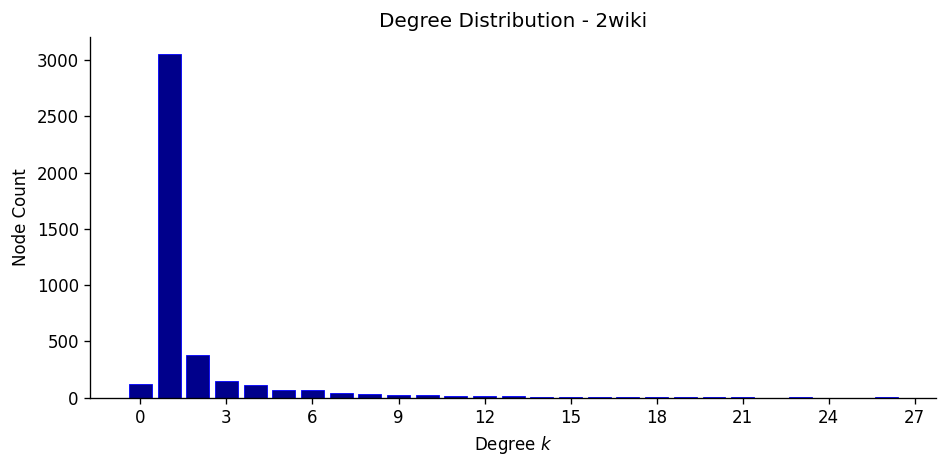

In [37]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(deg_values, deg_counts,
       color="darkblue", edgecolor="blue", linewidth=0.5)

ax.set_xlabel("Degree $k$")
ax.set_ylabel("Node Count")
ax.set_title(f"Degree Distribution - {dataset.capitalize()}")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()